In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = '/content/drive/MyDrive/Skin_Cancer_Classification'
print(os.listdir(path))

['Dataset Description - Skin Cancer Classification.txt', 'Test', 'Train']


In [ ]:
#@title ## 1.1 Verify GPU availability
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found. Enable GPU in Colab: Runtime → Change runtime type → GPU')
else:
    print(f'Using GPU: {device_name}')

Using GPU: /device:GPU:0


In [ ]:
#@title Clean Train & Test datasets (ignore .txt file)
import os, shutil
from PIL import Image

original_base = '/content/drive/MyDrive/Skin_Cancer_Classification'
clean_base = '/content/clean_dataset'

# Only process folders 'Train', 'Test' (skip any .txt or other files)
splits = ['Train', 'Test']

# Create clean directory structure
for split in splits:
    split_path = os.path.join(original_base, split)
    for class_name in os.listdir(split_path):
        os.makedirs(os.path.join(clean_base, split, class_name), exist_ok=True)

corrupt_count = 0
for split in splits:
    split_path = os.path.join(original_base, split)
    for class_name in os.listdir(split_path):
        class_dir = os.path.join(split_path, class_name)
        if not os.path.isdir(class_dir):
            continue   # skip non-folder items
        for img_name in os.listdir(class_dir):
            src = os.path.join(class_dir, img_name)
            dst = os.path.join(clean_base, split, class_name, img_name)
            try:
                img = Image.open(src)
                img.verify()
                img = Image.open(src)
                img.copy().save(dst)
            except Exception:
                corrupt_count += 1
                print(f'Corrupt removed: {src}')

print(f'Total corrupt files removed: {corrupt_count}')

Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0010579.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0010313.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0000309.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0000308.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0010486.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0000143.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/melanoma/ISIC_0010925.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/squamous cell carcinoma/ISIC_0031852.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/squamous cell carcinoma/ISIC_0026132.jpg
Corrupt removed: /content/drive/MyDrive/Skin_Cancer_Classification/Train/squamo

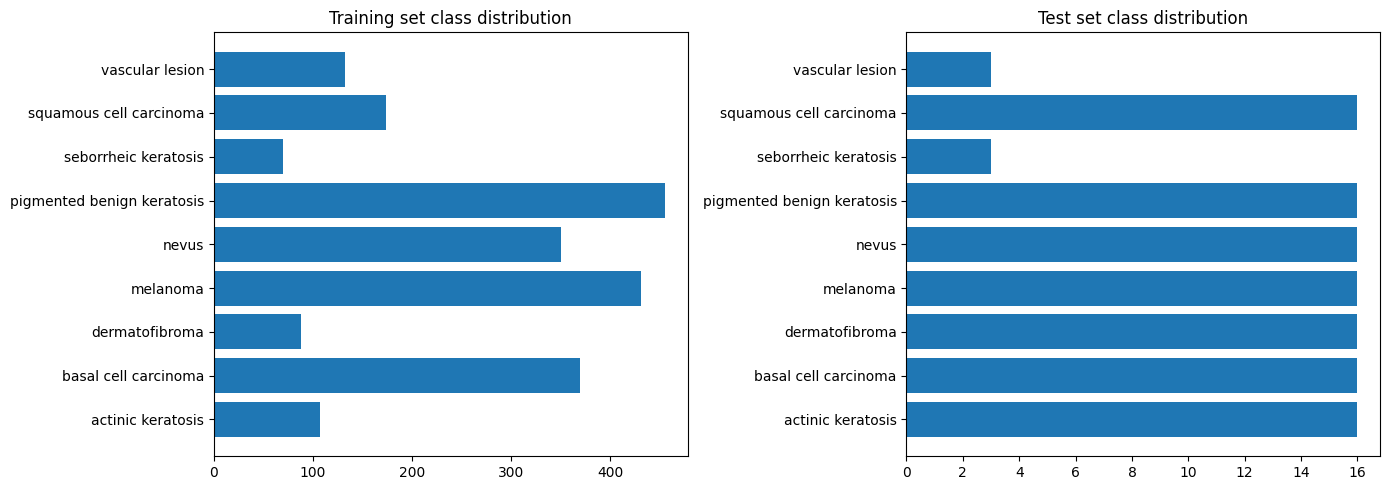

In [ ]:
#@title Class distribution (Train & Test)
import matplotlib.pyplot as plt
import os

clean_train = '/content/clean_dataset/Train'
clean_test = '/content/clean_dataset/Test'

def count_images(path):
    counts = {}
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(clean_train)
test_counts = count_images(clean_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.barh(list(train_counts.keys()), list(train_counts.values()))
ax1.set_title('Training set class distribution')
ax2.barh(list(test_counts.keys()), list(test_counts.values()))
ax2.set_title('Test set class distribution')
plt.tight_layout()
plt.show()

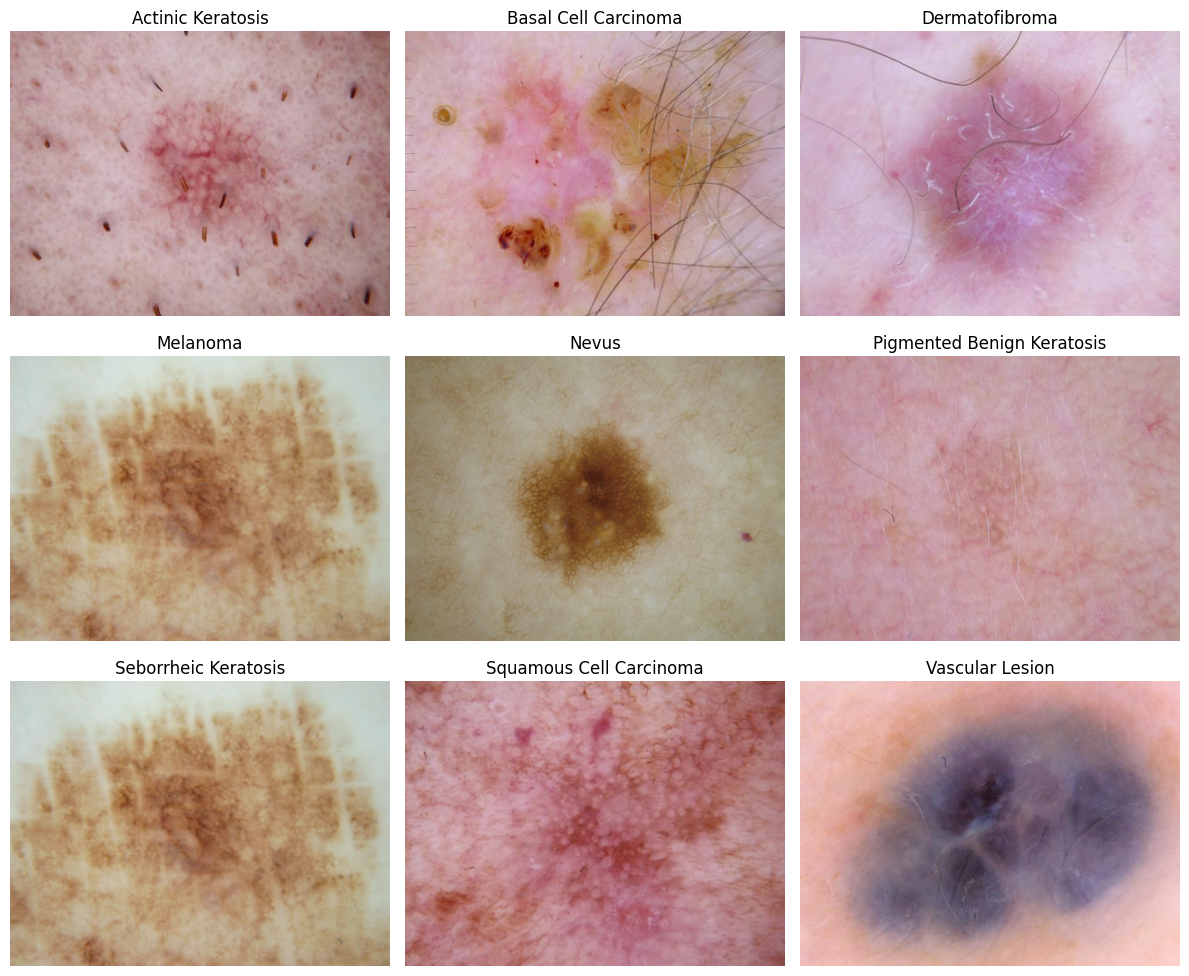

In [ ]:
#@title Show sample images (one per class)
import matplotlib.image as mpimg

classes = sorted(os.listdir(clean_train))
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(clean_train, cls)
    sample_img = os.listdir(cls_dir)[0]   # first image
    img = mpimg.imread(os.path.join(cls_dir, sample_img))
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].set_title(cls.replace('_',' ').title())
    axes[i//3, i%3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#@title Create Train/Val/Test generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2   # 20% of training data becomes validation
)

# No augmentation for test
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    clean_train,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    clean_train,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    clean_test,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Store class names and count
class_indices = train_generator.class_indices
num_classes = len(class_indices)
print("Classes:", class_indices)

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Classes: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [ ]:
#@title ## 5.1 Build Baseline CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,278,729 (84.99 MB)

 Trainable params: 22,278,729 (84.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title ## 5.2 Compile and train baseline
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 20

history_baseline = baseline_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 823ms/step - accuracy: 0.1922 - loss: 2.1966 - val_accuracy: 0.2019 - val_loss: 2.0641
Epoch 2/20
 1/54 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.1875 - loss: 2.0444

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.1875 - loss: 2.0444 - val_accuracy: 0.1995 - val_loss: 2.0354
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 686ms/step - accuracy: 0.2605 - loss: 1.9771 - val_accuracy: 0.2428 - val_loss: 1.9467
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.2812 - loss: 1.9456 - val_accuracy: 0.2380 - val_loss: 1.9630
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 706ms/step - accuracy: 0.3411 - loss: 1.7908 - val_accuracy: 0.3822 - val_loss: 1.7807
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.3438 - loss: 1.7536 - val_accuracy: 0.3630 - val_loss: 1.7551
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 755ms/step - accuracy: 0.4165 - loss: 1.6636 - val_accuracy: 0.4087 - val_loss: 1.7215
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.4062 - loss: 1.5734 - val_accuracy: 0.4255 - val_loss: 1.6725
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 677ms/step - accuracy: 0.4375 - loss: 1.6222 - val_accuracy: 0.4351 - 

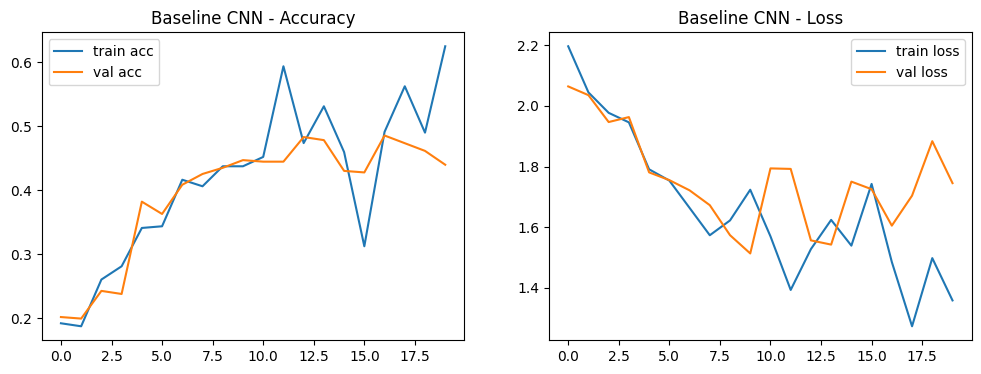

In [ ]:
#@title ## 5.3 Plot training curves
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(history.history['accuracy'], label='train acc')
    ax1.plot(history.history['val_accuracy'], label='val acc')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='train loss')
    ax2.plot(history.history['val_loss'], label='val loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.show()

plot_history(history_baseline, 'Baseline CNN')

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3051 - loss: 2.1835
Baseline Test Accuracy: 0.3051, Loss: 2.1835
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 716ms/step


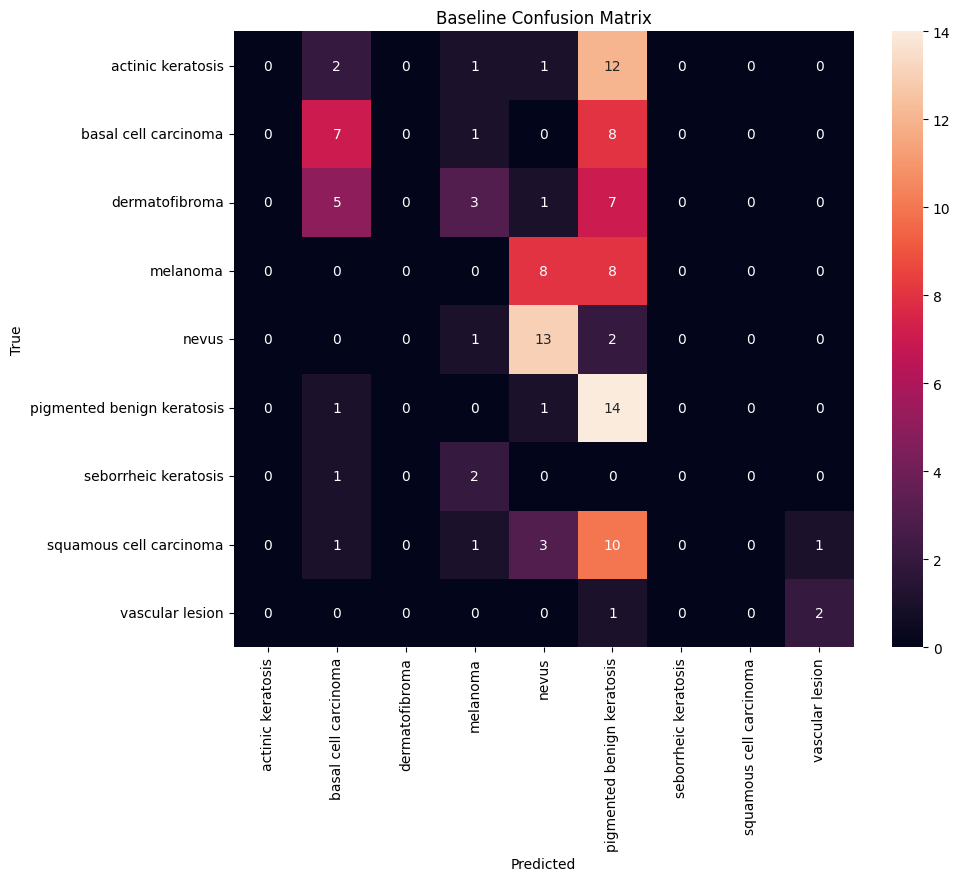

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.41      0.44      0.42        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.48      0.81      0.60        16
pigmented benign keratosis       0.23      0.88      0.36        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.67      0.67      0.67         3

                  accuracy                           0.31       118
                 macro avg       0.20      0.31      0.23       118
              weighted avg       0.17      0.31      0.21       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#@title ## 5.4 Evaluate on test set
test_loss, test_acc = baseline_model.evaluate(test_generator)
print(f'Baseline Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}')

# Predict and generate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
preds = baseline_model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_indices.keys(), yticklabels=class_indices.keys())
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_indices.keys()))

In [ ]:
#@title ## 6.1 Build Deeper CNN with BatchNorm and Dropout
from tensorflow.keras.layers import BatchNormalization

deeper_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 2,559,945 (9.77 MB)

 Trainable params: 2,557,449 (9.76 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
#@title ## 6.2 Train deeper model
deeper_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_deeper = deeper_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 866ms/step - accuracy: 0.2956 - loss: 2.3633 - val_accuracy: 0.1707 - val_loss: 2.1993
Epoch 2/20
 1/54 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.4062 - loss: 1.6717

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.4062 - loss: 1.6717 - val_accuracy: 0.1659 - val_loss: 2.1880
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 716ms/step - accuracy: 0.3855 - loss: 1.8021 - val_accuracy: 0.1731 - val_loss: 2.0620
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.3438 - loss: 1.8798 - val_accuracy: 0.1635 - val_loss: 2.0634
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 744ms/step - accuracy: 0.4246 - loss: 1.6616 - val_accuracy: 0.2067 - val_loss: 2.1153
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.3438 - loss: 1.8080 - val_accuracy: 0.2115 - val_loss: 2.1086
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 716ms/step - accuracy: 0.4141 - loss: 1.6312 - val_accuracy: 0.1731 - val_loss: 2.0457
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.4375 - loss: 1.5943 - val_accuracy: 0.1707 - val_loss: 2.0344
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 725ms/step - accuracy: 0.4445 - loss: 1.5907 - val_accuracy: 0.1779 - 

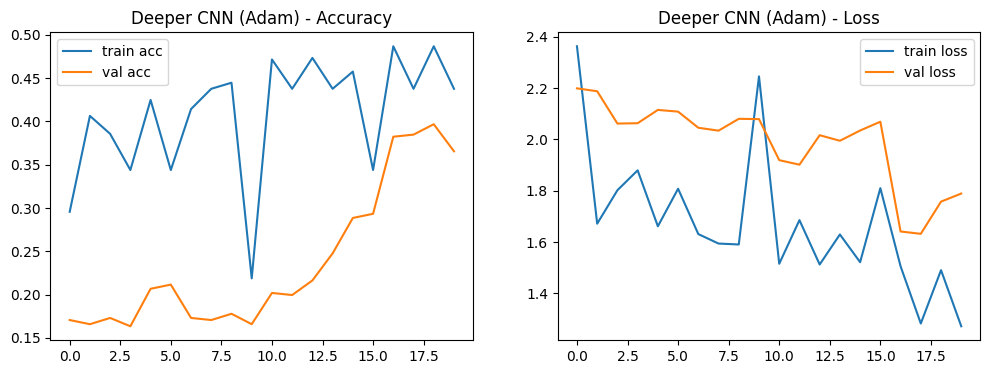

In [ ]:
#@title ## 6.3 Plot deeper model training curves
plot_history(history_deeper, 'Deeper CNN (Adam)')

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2712 - loss: 2.1751
Deeper Test Accuracy: 0.2712, Loss: 2.1751
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 762ms/step


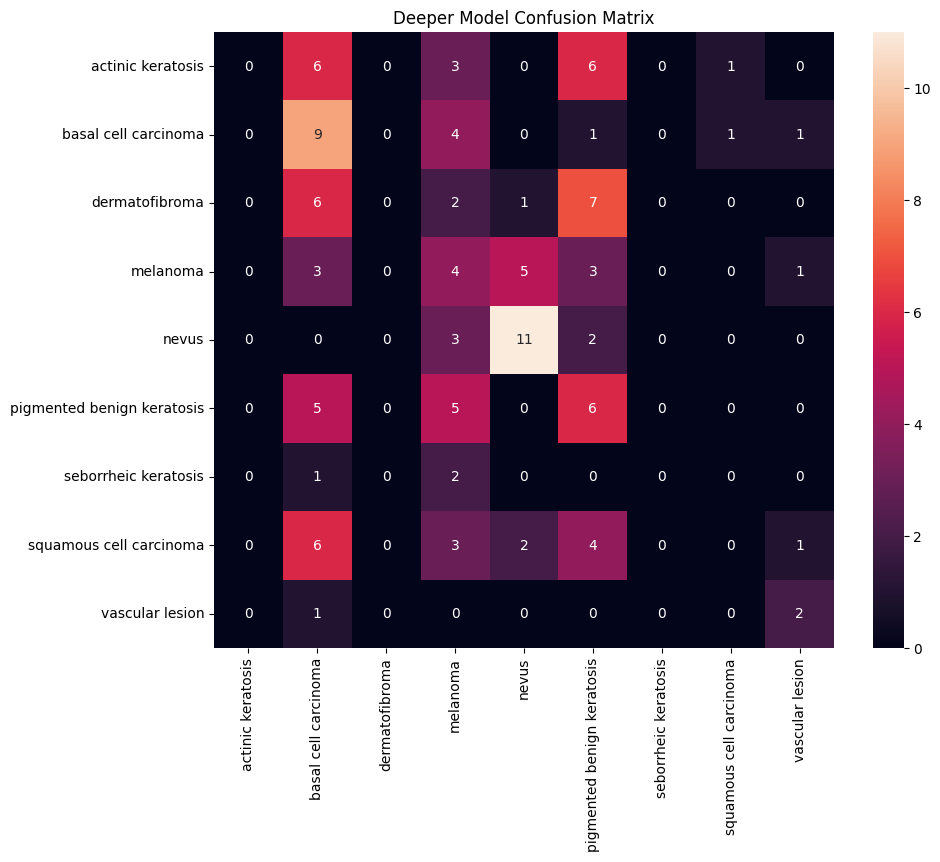

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.24      0.56      0.34        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.15      0.25      0.19        16
                     nevus       0.58      0.69      0.63        16
pigmented benign keratosis       0.21      0.38      0.27        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.40      0.67      0.50         3

                  accuracy                           0.27       118
                 macro avg       0.18      0.28      0.21       118
              weighted avg       0.17      0.27      0.21       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#@title ## 6.4 Evaluate deeper model
test_loss_deep, test_acc_deep = deeper_model.evaluate(test_generator)
print(f'Deeper Test Accuracy: {test_acc_deep:.4f}, Loss: {test_loss_deep:.4f}')

test_generator.reset()
preds_deep = deeper_model.predict(test_generator)
y_pred_deep = np.argmax(preds_deep, axis=1)
cm_deep = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(10,8))
sns.heatmap(cm_deep, annot=True, fmt='d', xticklabels=class_indices.keys(), yticklabels=class_indices.keys())
plt.title('Deeper Model Confusion Matrix')
plt.show()
print(classification_report(y_true, y_pred_deep, target_names=class_indices.keys()))

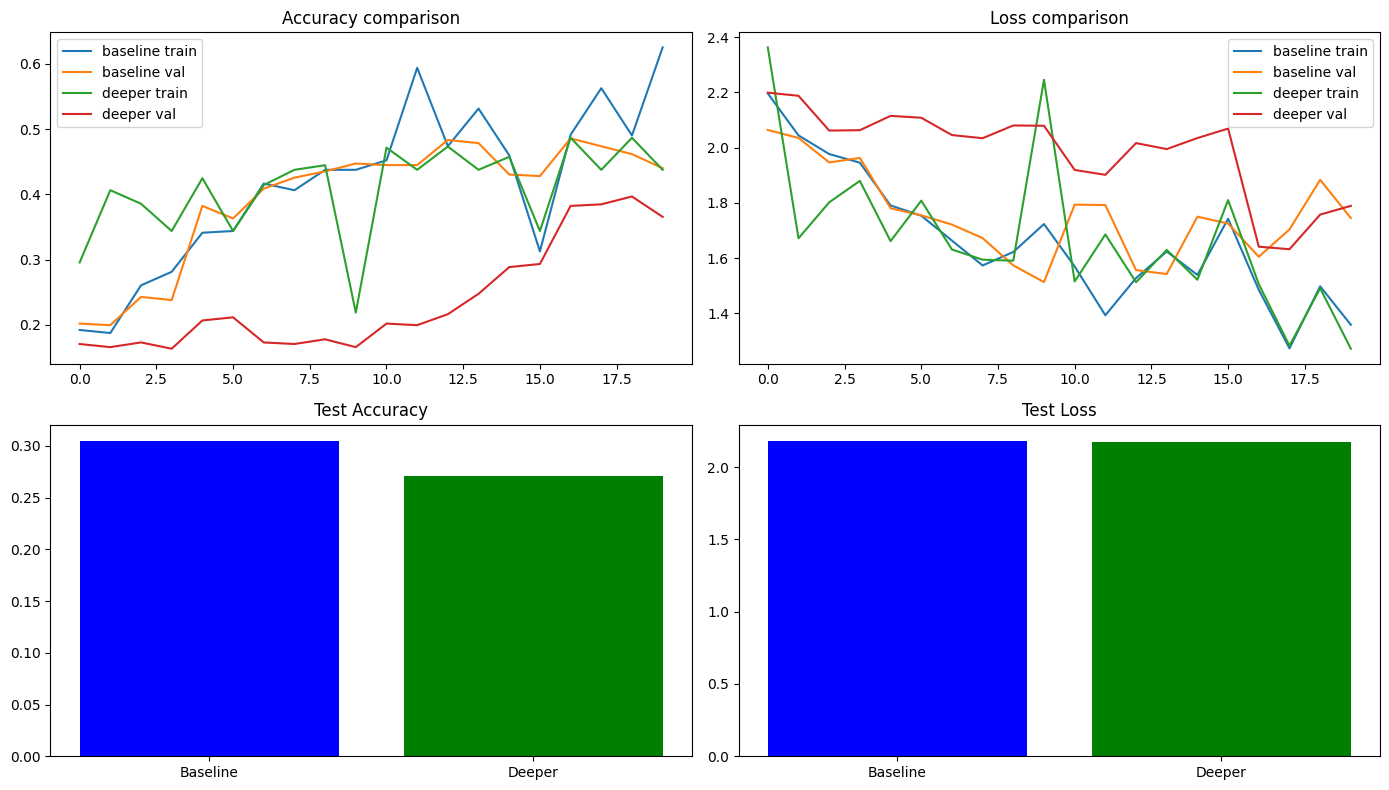

In [ ]:
#@title ## 7.1 Compare accuracy & loss curves
fig, axes = plt.subplots(2,2, figsize=(14,8))
axes[0,0].plot(history_baseline.history['accuracy'], label='baseline train')
axes[0,0].plot(history_baseline.history['val_accuracy'], label='baseline val')
axes[0,0].plot(history_deeper.history['accuracy'], label='deeper train')
axes[0,0].plot(history_deeper.history['val_accuracy'], label='deeper val')
axes[0,0].set_title('Accuracy comparison')
axes[0,0].legend()
axes[0,1].plot(history_baseline.history['loss'], label='baseline train')
axes[0,1].plot(history_baseline.history['val_loss'], label='baseline val')
axes[0,1].plot(history_deeper.history['loss'], label='deeper train')
axes[0,1].plot(history_deeper.history['val_loss'], label='deeper val')
axes[0,1].set_title('Loss comparison')
axes[0,1].legend()
axes[1,0].bar(['Baseline','Deeper'], [test_acc, test_acc_deep], color=['blue','green'])
axes[1,0].set_title('Test Accuracy')
axes[1,1].bar(['Baseline','Deeper'], [test_loss, test_loss_deep], color=['blue','green'])
axes[1,1].set_title('Test Loss')
plt.tight_layout()
plt.show()

In [ ]:
#@title ## 7.2 Train deeper model with SGD
from tensorflow.keras.optimizers import SGD

# Rebuild identical architecture
deeper_model_sgd = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

sgd = SGD(learning_rate=0.001, momentum=0.9)
deeper_model_sgd.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

history_sgd = deeper_model_sgd.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 823ms/step - accuracy: 0.2412 - loss: 2.5682 - val_accuracy: 0.1851 - val_loss: 2.1312
Epoch 2/20
 1/54 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.2188 - loss: 2.5552

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.2188 - loss: 2.5552 - val_accuracy: 0.2067 - val_loss: 2.1280
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 716ms/step - accuracy: 0.3551 - loss: 1.9178 - val_accuracy: 0.1659 - val_loss: 2.1630
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.4062 - loss: 1.6463 - val_accuracy: 0.1683 - val_loss: 2.1546
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 708ms/step - accuracy: 0.3756 - loss: 1.7615 - val_accuracy: 0.1707 - val_loss: 2.1218
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.5000 - loss: 1.7202 - val_accuracy: 0.1731 - val_loss: 2.1182
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 726ms/step - accuracy: 0.3949 - loss: 1.6965 - val_accuracy: 0.1875 - val_loss: 2.0954
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.3125 - loss: 1.7352 - val_accuracy: 0.2139 - val_loss: 2.1030
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 675ms/step - accuracy: 0.4265 - loss: 1.6512 - val_accuracy: 0.2548 - 

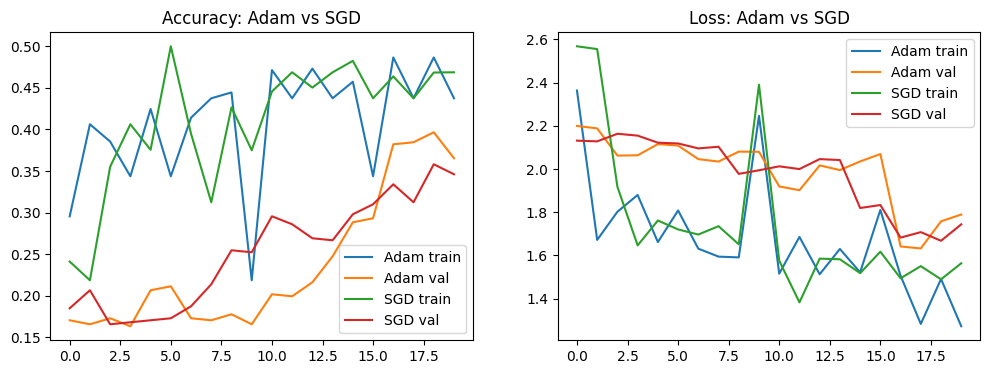

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.1864 - loss: 1.9728
SGD Test Accuracy: 0.1864, Adam Test Accuracy: 0.2712


In [ ]:
#@title ## 7.3 Compare convergence (Adam vs SGD)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.plot(history_deeper.history['accuracy'], label='Adam train')
ax1.plot(history_deeper.history['val_accuracy'], label='Adam val')
ax1.plot(history_sgd.history['accuracy'], label='SGD train')
ax1.plot(history_sgd.history['val_accuracy'], label='SGD val')
ax1.set_title('Accuracy: Adam vs SGD')
ax1.legend()
ax2.plot(history_deeper.history['loss'], label='Adam train')
ax2.plot(history_deeper.history['val_loss'], label='Adam val')
ax2.plot(history_sgd.history['loss'], label='SGD train')
ax2.plot(history_sgd.history['val_loss'], label='SGD val')
ax2.set_title('Loss: Adam vs SGD')
ax2.legend()
plt.show()

test_loss_sgd, test_acc_sgd = deeper_model_sgd.evaluate(test_generator)
print(f'SGD Test Accuracy: {test_acc_sgd:.4f}, Adam Test Accuracy: {test_acc_deep:.4f}')

In [ ]:
#@title ## 7.4 Ablation: build deeper model without Dropout
deeper_no_dropout = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    # No dropout here
    Dense(256, activation='relu'),
    # No dropout here
    Dense(num_classes, activation='softmax')
])

deeper_no_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_no_dropout = deeper_no_dropout.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

test_acc_no_drop, _ = deeper_no_dropout.evaluate(test_generator)
print(f'Deeper without Dropout Test Accuracy: {test_acc_no_drop:.4f}')
print(f'Deeper with Dropout Test Accuracy:    {test_acc_deep:.4f}')

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 804ms/step - accuracy: 0.3966 - loss: 1.7454 - val_accuracy: 0.1683 - val_loss: 2.1755
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.3750 - loss: 1.6861 - val_accuracy: 0.1683 - val_loss: 2.1711
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 679ms/step - accuracy: 0.4702 - loss: 1.5102 - val_accuracy: 0.1731 - val_loss: 2.3390
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.4375 - loss: 1.9684 - val_accuracy: 0.1707 - val_loss: 2.3204
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 692ms/step - accuracy: 0.4831 - loss: 1.4753 - val_accuracy: 0.1707 - val_loss: 2.1832
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.4062 - loss: 1.5430 - val_accuracy: 0.1707 - val_loss: 2.2102
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 713ms/step - accuracy: 0.4982 - loss: 1.4109 - val_accuracy: 0.1755 - val_loss: 2.2551
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.4375 - loss: 1.3946 - val_accuracy

In [ ]:
#@title ## 8.1 Load pre-trained VGG16 (without top) and add custom classifier
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False   # freeze feature extractor

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,329 (56.64 MB)

 Trainable params: 133,641 (522.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#@title ## 8.2 Feature extraction training
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_fe = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=10  # quick pass
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 900ms/step - accuracy: 0.1916 - loss: 2.1014 - val_accuracy: 0.2019 - val_loss: 1.9296
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.3125 - loss: 1.8699 - val_accuracy: 0.2067 - val_loss: 1.9304
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 747ms/step - accuracy: 0.2529 - loss: 1.9673 - val_accuracy: 0.3317 - val_loss: 1.8817
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.1250 - loss: 2.1716 - val_accuracy: 0.3389 - val_loss: 1.8597
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 733ms/step - accuracy: 0.2710 - loss: 1.9280 - val_accuracy: 0.3173 - val_loss: 1.8395
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.3438 - loss: 1.8133 - val_accuracy: 0.3341 - val_loss: 1.8385
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 746ms/step - accuracy: 0.2915 - loss: 1.8814 - val_accuracy: 0.3606 - val_loss: 1.7791
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.1875 - loss: 1.7603 - val_accurac

In [ ]:
#@title ## 8.3 Fine-tune (unfreeze last few conv blocks)
base_model.trainable = True
# Freeze all layers except the last 4 (block5) – adjust as needed
for layer in base_model.layers[:-4]:
    layer.trainable = False

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 829ms/step - accuracy: 0.3604 - loss: 1.7546 - val_accuracy: 0.3726 - val_loss: 1.6737
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.3750 - loss: 1.7850 - val_accuracy: 0.3702 - val_loss: 1.6794
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 745ms/step - accuracy: 0.4112 - loss: 1.6641 - val_accuracy: 0.4111 - val_loss: 1.6109
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.4062 - loss: 1.4480 - val_accuracy: 0.4111 - val_loss: 1.5935
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 760ms/step - accuracy: 0.4486 - loss: 1.5844 - val_accuracy: 0.4495 - val_loss: 1.5726
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.4688 - loss: 1.5374 - val_accuracy: 0.4447 - val_loss: 1.5683
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 727ms/step - accuracy: 0.4737 - loss: 1.5225 - val_accuracy: 0.4447 - val_loss: 1.5164
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.4375 - loss: 1.7078 - val_accurac

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.3220 - loss: 2.0270
Transfer Learning Test Accuracy: 0.3220


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 623ms/step


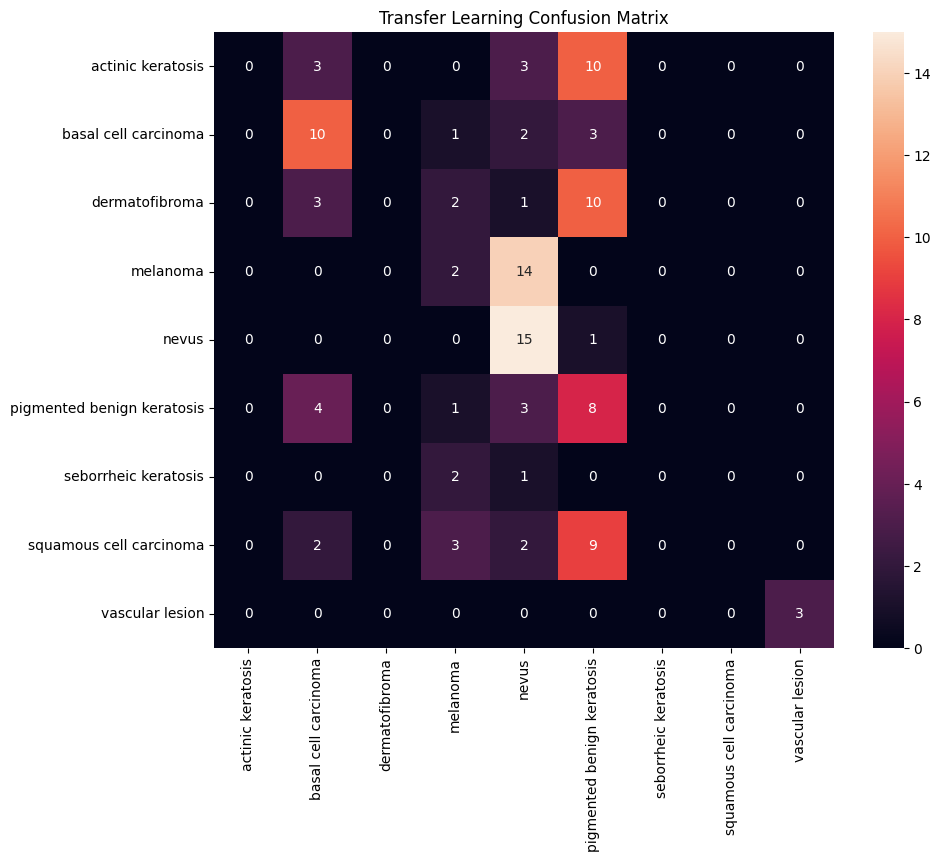

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.45      0.62      0.53        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.18      0.12      0.15        16
                     nevus       0.37      0.94      0.53        16
pigmented benign keratosis       0.20      0.50      0.28        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.32       118
                 macro avg       0.24      0.35      0.28       118
              weighted avg       0.19      0.32      0.23       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#@title ## 8.4 Test performance
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_generator)
print(f'Transfer Learning Test Accuracy: {test_acc_tl:.4f}')

test_generator.reset()
preds_tl = transfer_model.predict(test_generator)
y_pred_tl = np.argmax(preds_tl, axis=1)
cm_tl = confusion_matrix(y_true, y_pred_tl)
plt.figure(figsize=(10,8))
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=class_indices.keys(), yticklabels=class_indices.keys())
plt.title('Transfer Learning Confusion Matrix')
plt.show()
print(classification_report(y_true, y_pred_tl, target_names=class_indices.keys()))

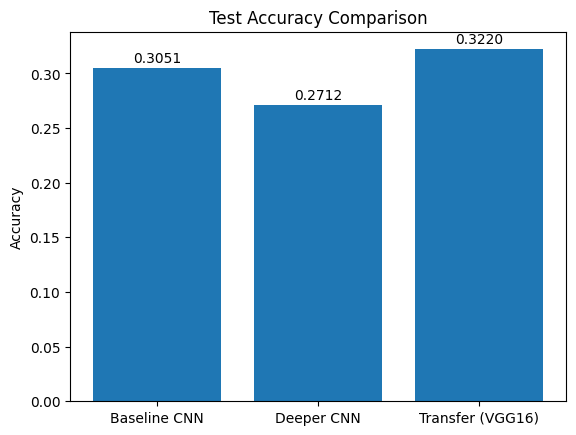

In [ ]:
#@title ## 8.5 Summary bar chart
accuracies = [test_acc, test_acc_deep, test_acc_tl]
labels = ['Baseline CNN', 'Deeper CNN', 'Transfer (VGG16)']
plt.bar(labels, accuracies)
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v+0.005, f'{v:.4f}', ha='center')
plt.show()